In [1]:
from enum import show_flag_values

import torch
from diffusers import FluxPipeline
from IPython.display import display
from datetime import datetime
from dotenv import load_dotenv
import os
from huggingface_hub import login

load_dotenv(dotenv_path="../.env", override=True)

HF_API_KEY = os.getenv("HF_API_KEY")

login(HF_API_KEY)

In [2]:
start = datetime.now()


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Token indices sequence length is longer than the specified maximum sequence length for this model (109 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['particularly around the chin and forehead. he ’ s wearing a grey shirt, and the background looks like a home kitchen with white cabinets and various household items visible']


  0%|          | 0/4 [00:00<?, ?it/s]

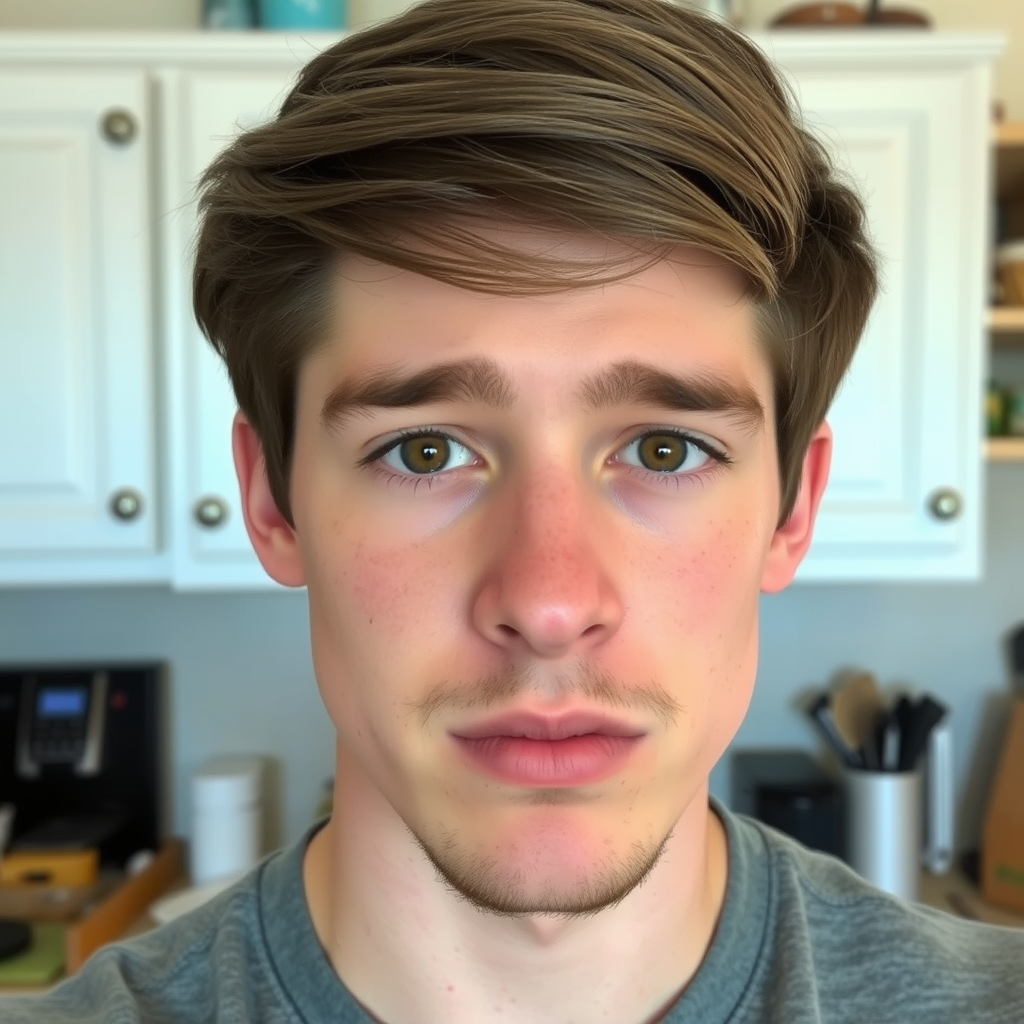

In [3]:
pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell", torch_dtype=torch.float32).to("mps")
generator = torch.Generator(device="mps").manual_seed(42)
#prompt = ("""a man standing over a turkey. The man has a nametag that says 'Zach' and has an axe in one of his hands.
#          The man is holding a wooden sign in his other hand that says 'happy thanksgiving'.
#          The turkey has a comical cartoonish grin on his face.""")
#prompt = ("""a young man standing in an apple store, holding a cellphone, trying to sell the cellphone to a customer standing next to them.
#        The man has a goatee, and a name tag that says 'Don'.
#        """)

prompt = ("""
a young adult with fair skin and straight, dark brown hair that’s brushed to the side. He has thick,
prominent eyebrows and brown eyes with a neutral, slightly tired expression.
His facial hair includes a mustache and a small patch of hair on his chin, with light stubble along the jawline and cheeks.
His complexion shows a few small blemishes, particularly around the chin and forehead.
""")

image = pipe(
    prompt,
    guidance_scale=0.0,
    num_inference_steps=4,
    max_sequence_length=256,
    generator=generator,
).images[0]

display(image)
stop=datetime.now()


In [11]:
#!uv add accelerate sentencepiece
#!uv add datasets
#!uv add soundfile
#!uv add bitsandbytes

⠙ bitsandbytes==0.48.2                                                          

python(4276) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Resolved 272 packages in 292ms                                       
error: Distribution `bitsandbytes==0.48.2 @ registry+https://pypi.org/simple` can't be installed because it doesn't have a source distribution or wheel for the current platform

hint: You're on macOS (`macosx_26_0_arm64`), but `bitsandbytes` (v0.48.2) only has wheels for the following platforms: `manylinux_2_24_aarch64`, `manylinux_2_24_x86_64`, `win_amd64`; consider adding "sys_platform == 'darwin' and platform_machine == 'arm64'" to `tool.uv.required-environments` to ensure uv resolves to a version with compatible wheels


In [1]:
from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch
from IPython.display import Audio

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='mps')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = synthesiser("Hi! Is this the Lodgeohdice residence? ... ... We are calling you about your extended car warranty.", forward_params={"speaker_embeddings": speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])

Device set to use mps
